In [1]:
import numpy as np # Import numpy library
import matplotlib.pyplot as plt # Import matplot library
import seaborn as sn # Import seaborn library
import pandas as pd # Import pandas library
import math # Import math library
import cv2
import datetime # Import datetime library
from keras.datasets import mnist, cifar10 # Import MNIST dataset
from keras.models import Sequential # Import Sequential class
from keras.layers import Dense, Flatten, Dropout, BatchNormalization# Import Dense, Flatten class
from keras import regularizers # Import regularizers
from tensorflow.keras.optimizers import Adam # Import Adam optimizer
# Import spare categorical crossentroy loss
from keras.metrics import sparse_categorical_crossentropy
from keras.callbacks import TensorBoard # Import TensorBoard class
from keras.models import load_model # Import load\_model method
from tensorflow.keras.utils import plot_model # Import plot\_model method
from tensorflow.math import confusion_matrix # Import confusion\_matrix method
from tensorflow.keras import activations # Import activations module
epochs = 20



In [2]:
# x_train is a NumPy array of grayscale image data
# y_train is a NumPy array of digit labels (in range 0-9)
# x_test is a NumPy array of grayscale image data
# y_test is a NumPy array of digit labels (in range 0-9)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Print the data shape
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test:', x_test.shape)
print('y_test:', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [3]:
model = Sequential() # Create a Sequential object
# Input layer
# Add a flatten layer to convert the image data to a single column
model.add(Flatten(input_shape=x_train.shape[1:]))
model.add(Dropout(0.25))
# Hidden layer 1
model.add(Dense(units=1024, activation=activations.leaky_relu,
kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
# Add a dense layer (fully-connected layer) and use ReLU activation function.
# This layer uses L2 loss, computed as l2 * reduce\_sum(square(x)), where l2 is 0.002
model.add(Dense(units=512, activation=activations.leaky_relu,kernel_regularizer=regularizers.l2(0.001)))
# Hidden layer 2
# Add a dense layer (fully-connected layer) and use ReLU activation function.
# This layer uses L2 loss, computed as l2 * reduce\_sum(square(x)), where l2 is 0.002
model.add(Dense(units=512, activation=activations.leaky_relu,
kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(Dense(units=128, activation=activations.leaky_relu,
kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(units=64, activation=activations.leaky_relu,
kernel_regularizer=regularizers.l2(0.001)))
# Output layer

# Add a dense layer (fully-connected layer) and use softmax activation function.
model.add(Dense(units=10, activation='softmax'))
# We apply kernel_regularizer to penalize the weights which are very large causing the
# network to overfit, after applying kernel\_regularizer the weights will become smaller.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,014,922 (15.32 MB)

 Trainable params: 4,011,850 (15.30 MB)

 Non-trainable params: 3,072 (12.00 KB)

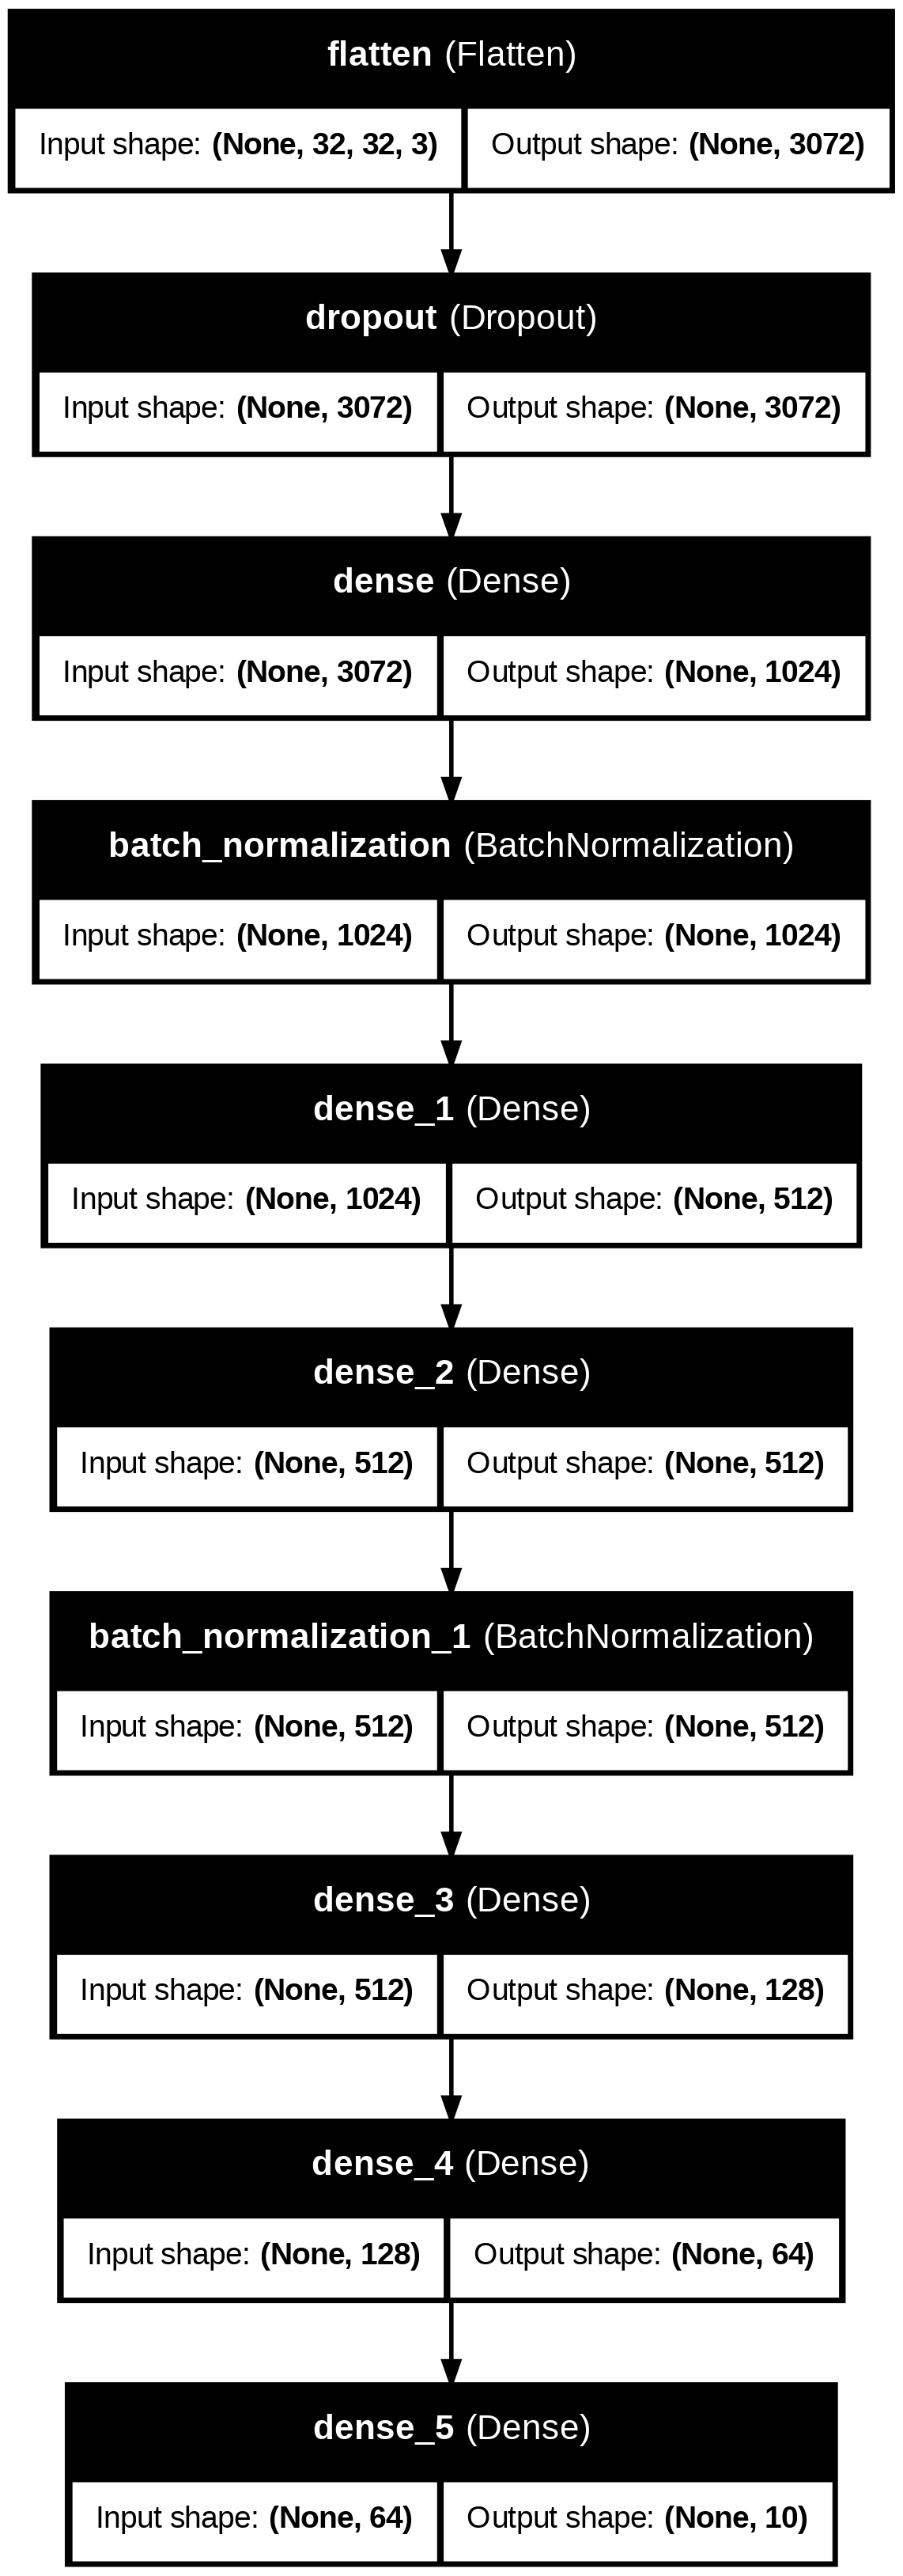

In [4]:
model.summary()
plot_model(model,
show_shapes=True,
show_layer_names=True)

In [5]:
# Create an Adam optimizer by creating an object
# Set learning rate to 0.001
# Note: Optimizers are Classes or methods used to change the attributes
# of your machine/deep learning model such as weights and learning rate
# in order to reduce the losses.
adam_optimizer = Adam(learning_rate=0.001)
# Compile the model, i.e., configures the model for training
# Use crossentropy loss function since there are two or more label classes.# Use adam algorithm (a stochastic gradient descent method)
# Use accuracy as metric, i.e., report on accuracy
model.compile(
optimizer=adam_optimizer,
loss=sparse_categorical_crossentropy,
metrics=['accuracy']
)


In [6]:
# TensorBoard is a visualization tool, enabling us to track metrics like
# loss and accuracy, visualize the model graph, view histograms.
log_dir=".logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# log\_dir: the path of the directory where to save the log files
# histogram\_freq: frequency (in epochs) at which to compute activation
# and weight histograms for the layers of the model
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)
# Fit the model, i.e., train the model
# Specify training data and labels, number of epochs to train the model,
# validation data, i.e., data on which to evaluate the loss
# Write TensorBoard logs after every batch of training to monitor
training_history = model.fit(x_train, y_train, epochs=epochs,
validation_data=(x_test, y_test),
callbacks=[tensorboard_callback]
)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 83ms/step - accuracy: 0.3247 - loss: 3.0147 - val_accuracy: 0.2278 - val_loss: 2.7521
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 149s 88ms/step - accuracy: 0.3418 - loss: 2.2180 - val_accuracy: 0.3035 - val_loss: 2.2636
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 83ms/step - accuracy: 0.3489 - loss: 2.1396 - val_accuracy: 0.2788 - val_loss: 2.2602
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.3570 - loss: 2.0930 - val_accuracy: 0.3150 - val_loss: 2.1880
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 84ms/step - accuracy: 0.3652 - loss: 2.0414 - val_accuracy: 0.3186 - val_loss: 2.1060
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 156s 93ms/step - accuracy: 0.3731 - loss: 1.9908 - val_accuracy: 0.3064 - val_loss: 2.1228
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 188s 84ms/step - accuracy: 0.3825 - loss: 1.9527 - val_accuracy: 0.3883 - val_loss: 1.9530
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 

In [7]:
# Evaluate the model
# Specify testing data and labels
validation_loss, validation_accuracy = model.evaluate(x_test, y_test)
# Print loss and accuracy
print('Validation loss: ', validation_loss)
print('Validation accuracy: ', validation_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4199 - loss: 1.7890
Validation loss:  1.7889976501464844
Validation accuracy:  0.41990000009536743


In [10]:
model_name = 'CIFAR-10-mlp.h5'
model.save(model_name, save_format='h5')
loaded_model = load_model(model_name)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 32, 32, 3))',)
  warnings.warn(msg)


predictions: (10000, 10)
[1.e+03 1.e+07]


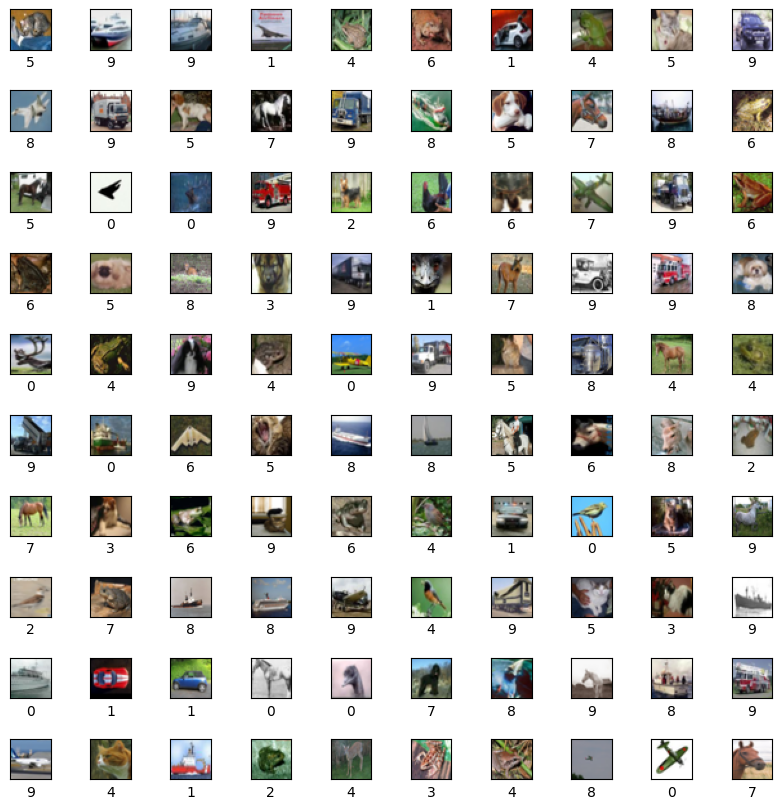

In [12]:
predictions = loaded_model.predict([x_test])
print('predictions:', predictions.shape)
pd.DataFrame(predictions)
prediction_results = np.argmax(predictions, axis=1)
pd.DataFrame(prediction_results)
numbers_to_display = 100 # Display 196 images
# Compute number of images per row
num_cells = math.ceil(math.sqrt(numbers_to_display))
plt.figure(figsize=(10, 10)) # Each image is in size 10x10 inches
# Show all the images
for i in range(numbers_to_display):
  # Number of rows, number of columns, index (start from 1)
  plt.subplot(num_cells, num_cells, i + 1)
  plt.xticks([]) # Remove all xticks
  plt.yticks([]) # Remove all yticks
  plt.grid(False) # No grid lines
  # Check if the prediction is correct. If so, display in green.
  # Otherwise in red.
  color_map = 'Greens' if prediction_results[i] == y_test[i] else 'Reds'
  plt.imshow(x_test[i], cmap=color_map) # Display data as a color image
  plt.xlabel(prediction_results[i]) # Show predicted image labels
# Adjust the height of the padding between subplots to 1
# Adjust the width of the padding between subplots to 0.5
accuracy = (prediction_results == y_test).sum()/y_test.shape
print(accuracy)
plt.subplots_adjust(hspace=1, wspace=0.5)
plt.show() # Show the figure